# Hotel Booking: cómo afectan las cancelaciones a los hoteles

Las cancelaciones de reservas representan un desafío para la industria hotelera, ya que generan pérdidas en los ingresos, provocan una mala planificación en la ocupación y derivan en sobrecostes operativos. Estas cancelaciones pueden estar relacionadas con factores como políticas de cancelación flexibles, el uso de múltiples plataformas de reserva o la ausencia de penalizaciones por cancelar en el último minuto, entre otras.

El dataset analizado recoge reservas realizadas entre el año 2015 y 2017, de las que aproximadamente un 37% son reservas canceladas, lo que indica la importancia de este fenómeno durante este periodo. El objetivo de este estudio es desarrollar un modelo de clasificación binaria capaz de predecir con antelación la probabildiad de cancelación de una reserva, permitiendo a los hoteles elaborar estrategias de actuación que reduzcan el impacto económico y operativo de las cancelaciones, apoyándose en datos históricos.

Este problema se puede abordar con Machine Learning porque disponemos de un historial de reservas con múltiples variables predictoras (tipo de hotel, tiempo de anticipación, número de adultos, plataforma de reserva, etc.) y un target binario (cancelada/no cancelada). Existen patrones en los datos que los algoritmos de clasificación supervisada pueden aprender para predecir futuras cancelaciones.

Se propone un enfoque de clasificación supervisada, porque el objetivo es predecir una variable binaria conocida a partir de características históricas. Este enfoque permite estimar probabilidades de cancelación para nuevas reservas y, por tanto, guiar decisiones operativas. Algoritmos como Random Forest, XGBoost o regresión logística son adecuados dado que manejan variables categóricas y numéricas, toleran relaciones no lineales y permiten interpretar la importancia de las variables.


In [530]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.model_selection import train_test_split

np.random.seed(42)


#### Carga de datos, primer vistazo y descripción:

In [531]:
df = pd.read_csv("../data_sample/hotel_booking.csv", sep= ",")
df.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Jasmine Fletcher,JFletcher43@xfinity.com,190-271-6743,************9263
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,Transient,107.0,0,0,Check-Out,2015-07-03,Dylan Rangel,Rangel.Dylan@comcast.net,420-332-5209,************6994
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,Transient,103.0,0,1,Check-Out,2015-07-03,William Velez,Velez_William@mail.com,286-669-4333,************8729
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,Transient,82.0,0,1,Canceled,2015-05-06,Steven Murphy,Steven.Murphy54@aol.com,341-726-5787,************3639
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,Transient,105.5,0,0,Canceled,2015-04-22,Michael Moore,MichaelMoore81@outlook.com,316-648-6176,************9190


In [532]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [533]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


#### Columnas irrelevantes para nuestro modelo:
En este caso, las columnas como **"name"**, **"email"**, **"phone-number"**, **"credit_card"** no son de utilidad para nuestro modelo. Las eliminaremos de nuestro dataset.

#### Data leakage:
Por otro lado, hay algunas variables cuya información es obtenida después de haber realizado una reserva, y nuestro modelo va a predecir la cancelación antes de que ocurra. Al ser data leakage, las podemos descartar:
- **reservation_status** tiene información acerca de si hicieron check-out, cancelaron o no se presentaron. Esta variable describe el resultado final de la reserva.
- **reservation_status_date** indica la fecha en la que el resultado final de la reserva se registró, contiene información futura para nuestro modelo. 

In [534]:
df.reservation_status.value_counts()

reservation_status
Check-Out    75166
Canceled     43017
No-Show       1207
Name: count, dtype: int64

In [535]:
df.reservation_status_date.value_counts()

reservation_status_date
2015-10-21    1461
2015-07-06     805
2016-11-25     790
2015-01-01     763
2016-01-18     625
              ... 
2015-02-26       1
2015-03-18       1
2015-03-12       1
2015-03-11       1
2015-06-14       1
Name: count, Length: 926, dtype: int64

#### Nulos: 
Tenemos 4 variables con nulos: children, country, agent y company, que trataremos más adelante.  
- **children:** Al ser pocos nulos, los rellenaremos con la media.
- **country:** Son pocos respecto al total del dataset y son información útil para el modelo, por lo que usaremos la moda para rellenarlos.
- **agent:** es un ID del agente de viaje que realizó la reserva. Hay muchos nulos, y no aportan información relevante al modelo, podemos prescindir de ella.
- **company:** es un ID de la empresa que realizó la reserva. Con la cantidad de nulos que tiene, no es útil para nuestro modelo.

In [536]:
df.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [537]:
df.agent.value_counts()

agent
9.0      31961
240.0    13922
1.0       7191
14.0      3640
7.0       3539
         ...  
197.0        1
294.0        1
388.0        1
453.0        1
480.0        1
Name: count, Length: 333, dtype: int64

In [538]:
df.company.value_counts()

company
40.0     927
223.0    784
67.0     267
45.0     250
153.0    215
        ... 
18.0       1
273.0      1
368.0      1
393.0      1
132.0      1
Name: count, Length: 352, dtype: int64

#### Duplicados:
En este dataset, no tenemos filas duplicadas.

In [539]:
df.duplicated().sum()

np.int64(0)

#### Columnas elegidas:

In [540]:
df_hotel = df.copy()

columns_to_drop = ["name", "email", "phone-number", "credit_card", "reservation_status", "reservation_status_date", "agent", "company"]
df_hotel = df_hotel.drop(columns=columns_to_drop)

df_hotel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 28 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

## Análisis inicial del dataset 
El dataset tiene un total de 119.390 filas y 36 columnas inicialmente. Tras eliminar las columnas que no usaremos en nuestro modelo, continuaremos con 28 columnas. De estas, 10 son tipo string, 16 de tipo int y 2 de tipo float. 

### Clasificación inicial de variables: 

- **Variables numéricas continuas:** 
    - lead_time
    - adr 

- **Variables numéricas discretas:** 
    - adults
    - children
    - babies
    - required_car_parking_spaces
    - total_of_special_requests
    - days_in_waiting_list
    - previous_cancellations
    - previous_bookings_not_canceled
    - booking_changes
    - stays_in_week_nights
    - stays_in_weekend_nights
    - arrival_date_year
    - arrival_date_day_of_month
    - arrival_date_week_number

- **Variables categóricas:**
    - hotel
    - customer_type
    - market_segment
    - deposit_type
    - meal
    - country
    - distribution_channel
    - reserved_room_type
    - assigned_room_type
    - arrival_date_month

- **Variables binarias:** 
    - is_repeated_guest

- **Variable objetivo:** 
    - is_canceled

La tipificación inicial se realizó inspeccionando las variables y sus valores únicos, asegurando que la separación entre continuas, discretas, categóricas, binarias y temporales sea coherente con la naturaleza de los datos.



### Análisis del target - is_canceled:

En nuestra variable target interpretamos que el valor que es 0 se refiere a "no" y 1 significa "sí". No hay un desbalance grande, y nos sirve para confirmar que las cancelaciones son un problema relevante. En nuestro dataframe, un 62% de las reservas no son canceladas, frente al 37% que sí cancelan. 

In [541]:
df_hotel["is_canceled"].value_counts(normalize=True)

is_canceled
0    0.629584
1    0.370416
Name: proportion, dtype: float64

In [542]:
target = "is_canceled"

### Train/Test split:


In [543]:
# tenemos nuestro df_hotel limpio y sin columnas irrelevantes:
X = df_hotel.drop(columns="is_canceled")
y = df_hotel["is_canceled"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

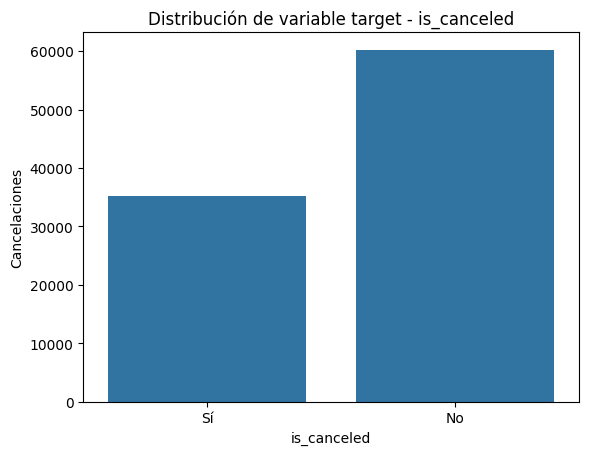

In [544]:
# vemos la distribución del target, donde 0 es "No" y 1 es "Sí" y usamos map para cambiar
# estos valores y visualizar:
y_train_etiquetas = y_train.map({0: "No", 1: "Sí"})

sns.countplot(x=y_train_etiquetas)
plt.title("Distribución de variable target - is_canceled")
plt.ylabel("Cancelaciones")
plt.show();

In [545]:
# Vemos el porcentaje de cancelaciones en nuestro train, muy similar al df original:
print(y_train.value_counts(normalize=True) * 100)


is_canceled
0    63.090502
1    36.909498
Name: proportion, dtype: float64


## Análisis de variables numéricas:


### Numéricas continuas:

In [546]:
# lead_time:
sns.histplot(train_set["lead_time"], bins=50, kde=True, color="skyblue")
plt.title("Distribución de lead_time")
plt.xlabel("Días entre reserva y llegada")
plt.ylabel("Número de reservas")
plt.show();

NameError: name 'train_set' is not defined

/var/folders/r5/mbjy65314c11vp7t3hw_9m7m0000gn/T/ipykernel_4554/1428295500.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="is_canceled", y="lead_time", data=train_set, palette=["lightgreen","salmon"])


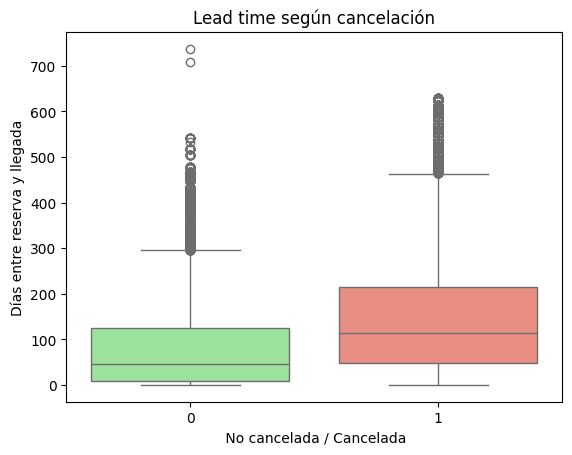

In [ ]:
# Lead time vs cancelación:
sns.boxplot(x="is_canceled", y="lead_time", data=train_set, palette=["lightgreen","salmon"])
plt.title("Lead time según cancelación")
plt.xlabel(" No cancelada / Cancelada")
plt.ylabel("Días entre reserva y llegada")
plt.show();

- Las reservas que se cancelan tienen un mayor espacio en días entre reserva y llegada.
- Las reservas que se mantienen se hacen con menor antelación.
- La mediana en las reservas canceladas es más alta que la mediana de las que se mantienen; esto quiere decir que cuanto más días hay entre reserva y llegada, mayor es la probabilidad de que se cancele.

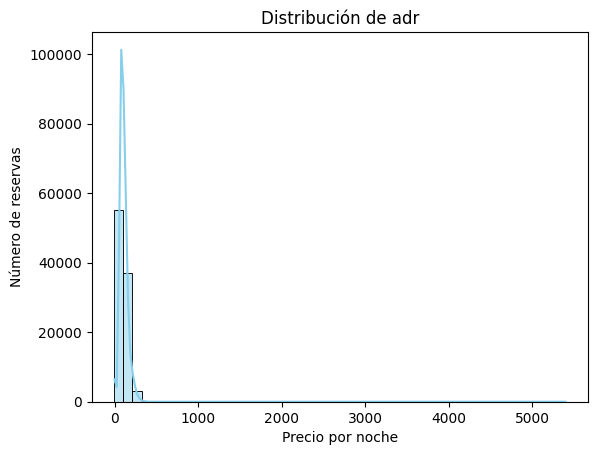

In [ ]:
# adr (average daily rate):
sns.histplot(train_set["adr"], bins=50, kde=True, color="skyblue")
plt.title("Distribución de adr")
plt.xlabel("Precio por noche")
plt.ylabel("Número de reservas")
plt.show();

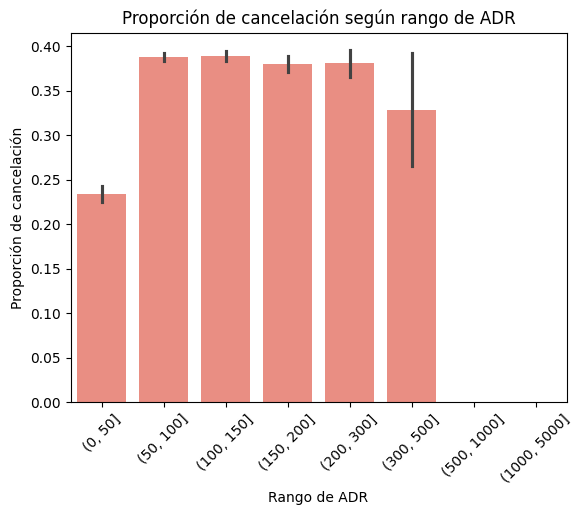

In [ ]:
# adr vs cancelación:

# Crear bins de ADR
bins = [0, 50, 100, 150, 200, 300, 500, 1000, 5000]
train_set["adr_range"] = pd.cut(train_set["adr"], bins)

sns.barplot(x="adr_range", y="is_canceled", data=train_set, color="salmon")
plt.xticks(rotation=45)
plt.ylabel("Proporción de cancelación")
plt.xlabel("Rango de ADR")
plt.title("Proporción de cancelación según rango de ADR")
plt.show()

- Las reservas con costo inferior a 50€ tienen una proporción de cancelación menor respecto a las reservas entre 50 y 300 aproximadamente. Además, la confianza en la proporción es buena, exceptuando para los rangos a partir de 300€ donde la confianza en la proporción baja y hay mucha variabilidad en los datos. 
- Al tener una escala muy grande (de 0-5000), para poder utilizarla en nuestro modelo y ya que aporta información importante, deberemos transformar la variable (con un log-transform para reducir el efecto de los valores grandes).

### Numéricas discretas:

In [ ]:
# vemos los valores de las variables discretas para entender su distribución:
vars_discretas = ["adults","children","babies","required_car_parking_spaces",
             "total_of_special_requests","days_in_waiting_list",
             "previous_cancellations","previous_bookings_not_canceled",
             "booking_changes","stays_in_week_nights","stays_in_weekend_nights",
             "arrival_date_year","arrival_date_day_of_month","arrival_date_week_number"]

for col in vars_discretas:
    print(f"Para la columna '{col}' hay:")
    print(train_set[col].value_counts())
    print("\n")

Para la columna 'adults' hay:
adults
2     71673
1     18463
3      4989
0       323
4        52
26        5
27        2
6         1
20        1
50        1
5         1
40        1
Name: count, dtype: int64


Para la columna 'children' hay:
children
0.0     88640
1.0      3888
2.0      2926
3.0        53
10.0        1
Name: count, dtype: int64


Para la columna 'babies' hay:
babies
0     94764
1       738
2         9
10        1
Name: count, dtype: int64


Para la columna 'required_car_parking_spaces' hay:
required_car_parking_spaces
0    89557
1     5929
2       22
3        2
8        2
Name: count, dtype: int64


Para la columna 'total_of_special_requests' hay:
total_of_special_requests
0    56190
1    26641
2    10377
3     2011
4      261
5       32
Name: count, dtype: int64


Para la columna 'days_in_waiting_list' hay:
days_in_waiting_list
0      92548
39       180
58       139
44       110
31        99
       ...  
73         1
116        1
117        1
193        1
185        1


In [ ]:
# para visualizar mis variables, voy a usar un set solo del train donde estén juntas las variables y el target:
train_set = X_train.copy()
train_set[target] = y_train
train_set.head()

,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,is_canceled
67702,City Hotel,64,2017,May,18,6,2,1,3,0.0,...,D,D,0,No Deposit,0,Transient,189.00,0,0,1
115851,City Hotel,34,2017,July,28,10,1,1,2,1.0,...,A,A,0,No Deposit,0,Transient,146.00,0,0,0
57345,City Hotel,8,2016,September,39,24,1,1,2,2.0,...,F,F,0,No Deposit,0,Transient,259.00,0,0,1
11622,Resort Hotel,251,2017,May,21,21,2,4,2,0.0,...,E,E,0,No Deposit,0,Transient,89.70,0,1,1
33333,Resort Hotel,23,2017,February,7,18,1,1,2,0.0,...,D,D,0,No Deposit,0,Transient,42.43,0,1,0


#### Variables con rangos de valores bajos:

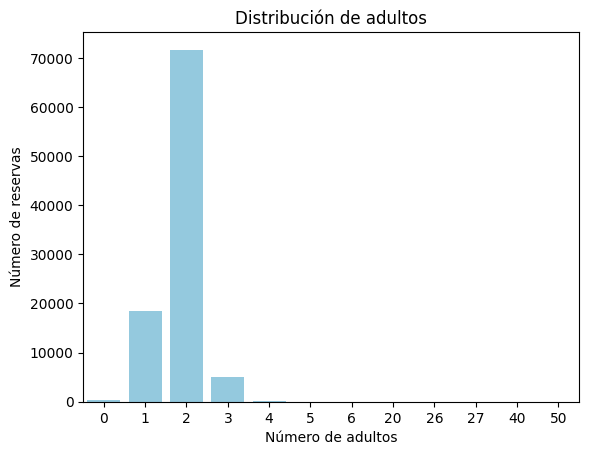

In [ ]:
sns.countplot(x="adults", data=train_set, color="skyblue")
plt.title("Distribución de adultos")
plt.xlabel("Número de adultos")
plt.ylabel("Número de reservas")
plt.show();

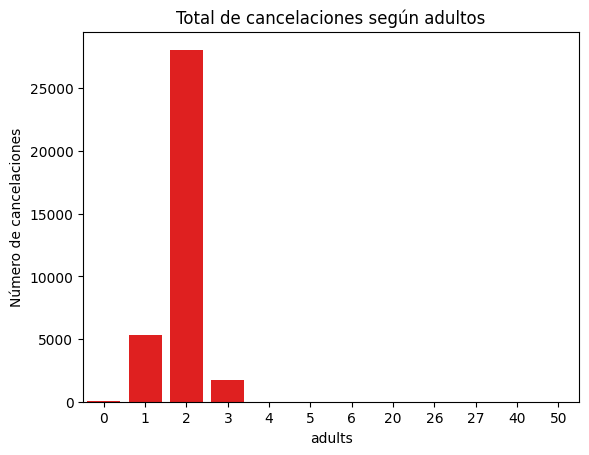

In [ ]:
# relación con el target:
sns.countplot(x="adults", data=train_set[train_set["is_canceled"]==1], color="red")
plt.title("Total de cancelaciones según adultos")
plt.ylabel("Número de cancelaciones")
plt.show();

- Los adultos que viajan en pareja tienden a reservar mucho más que el resto de grupos, pero también una tendencia mayor a cancelar la reserva.

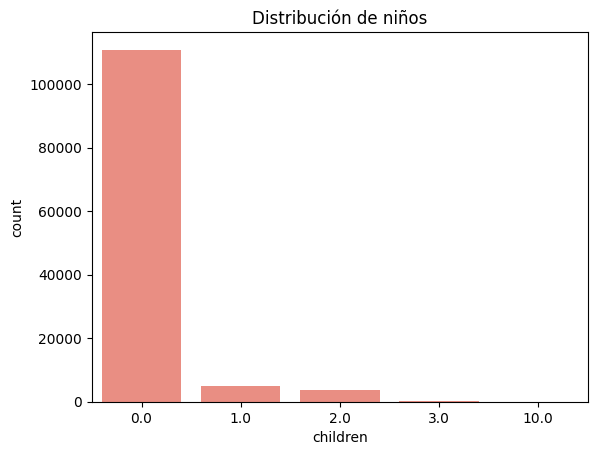

In [ ]:
sns.countplot(x="children", data=train_set, color="salmon")
plt.title("Distribución de niños")
plt.show();

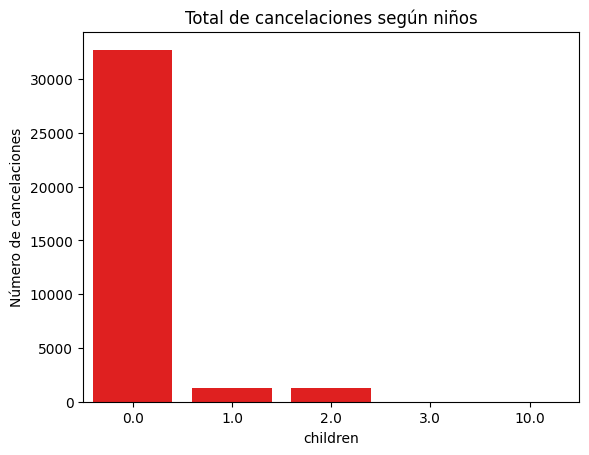

In [ ]:
sns.countplot(x="children", data=train_set[train_set["is_canceled"]==1], color="red")
plt.title("Total de cancelaciones según niños")
plt.ylabel("Número de cancelaciones")
plt.show();

- Podemos apreciar que las personas que cancelan las reservas en su mayoría no tienen niños.

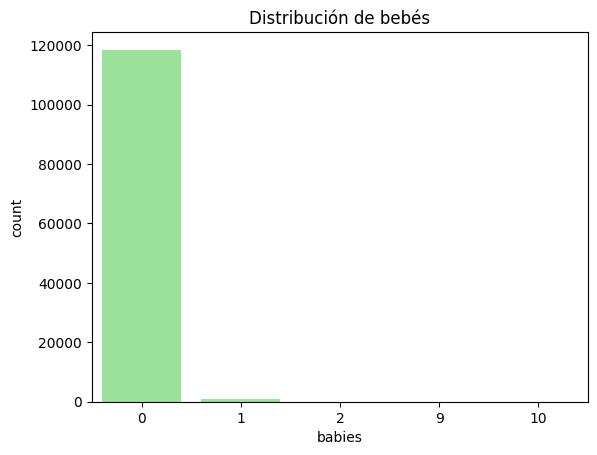

In [ ]:
sns.countplot(x="babies", data=train_set, color="lightgreen")
plt.title("Distribución de bebés")
plt.show();

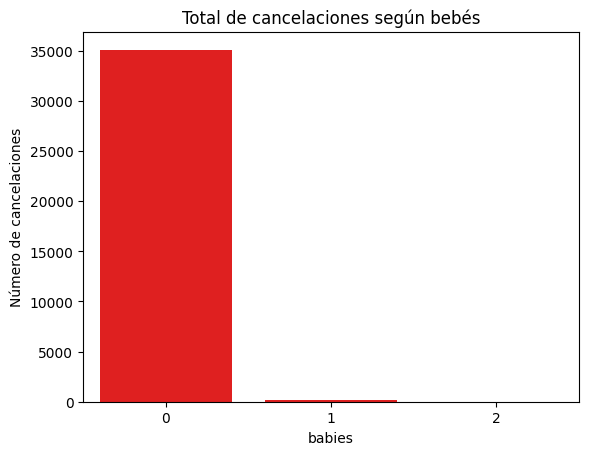

In [ ]:
sns.countplot(x="babies", data=train_set[train_set["is_canceled"]==1], color="red")
plt.title("Total de cancelaciones según bebés")
plt.ylabel("Número de cancelaciones")
plt.show();

- Asimismo, la mayoría de cancelaciones son de personas que viajan sin bebés también.

#### Variables con rango de valores medio:

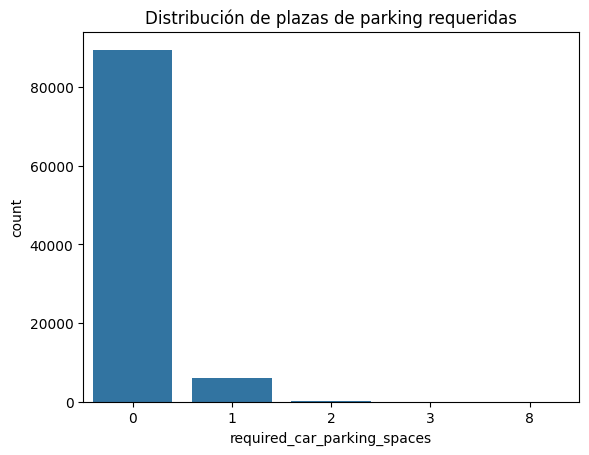

In [ ]:
sns.countplot(x="required_car_parking_spaces", data=train_set)
plt.title("Distribución de plazas de parking requeridas")
plt.show();

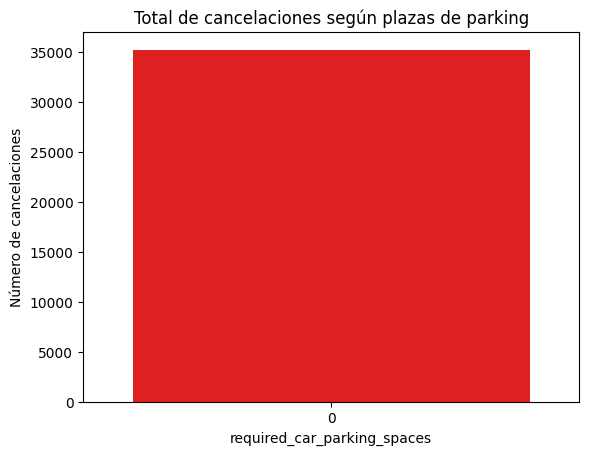

In [ ]:
# relación con target:
sns.countplot(x="required_car_parking_spaces", data=train_set[train_set["is_canceled"]==1], color="red")
plt.title("Total de cancelaciones según plazas de parking")
plt.ylabel("Número de cancelaciones")
plt.show();

- La mayoría de reservas realizadas no solicitan plaza de parking, por lo que no hay influencia en las reservas canceladas los hoteles que dispongan de parking.

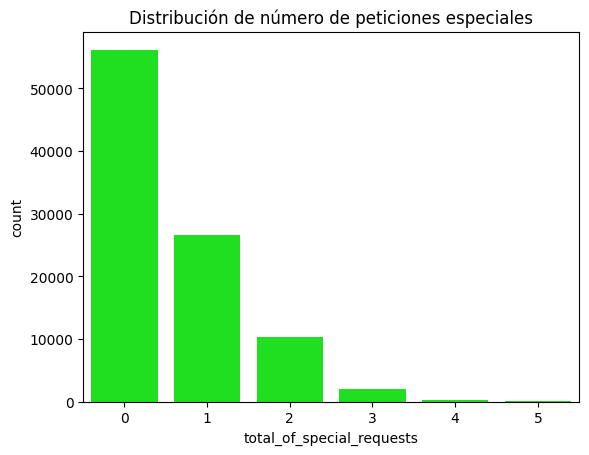

In [ ]:
# total_of_special_requests:
sns.countplot(x="total_of_special_requests", data= train_set, color="lime")
plt.title("Distribución de número de peticiones especiales")
plt.show();

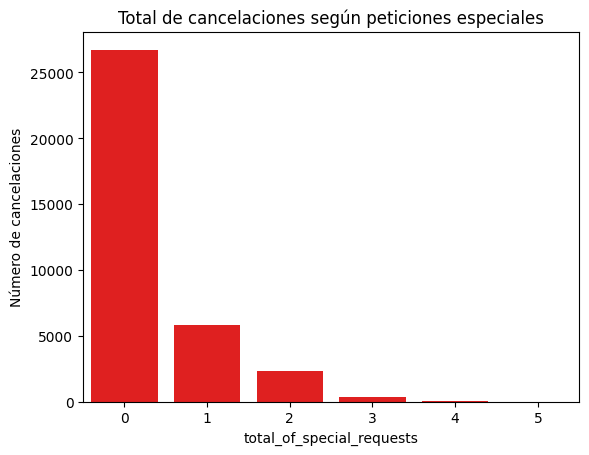

In [ ]:
# relación con target:
sns.countplot(x="total_of_special_requests", data= train_set[train_set["is_canceled"]==1], color="red")
plt.title("Total de cancelaciones según peticiones especiales")
plt.ylabel("Número de cancelaciones")
plt.show();

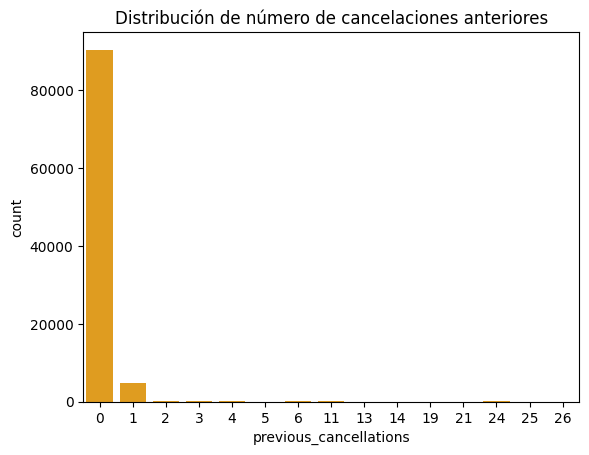

In [ ]:
# previous_cancelations:
sns.countplot(x="previous_cancellations", data= train_set, color="orange")
plt.title("Distribución de número de cancelaciones anteriores")
plt.show();

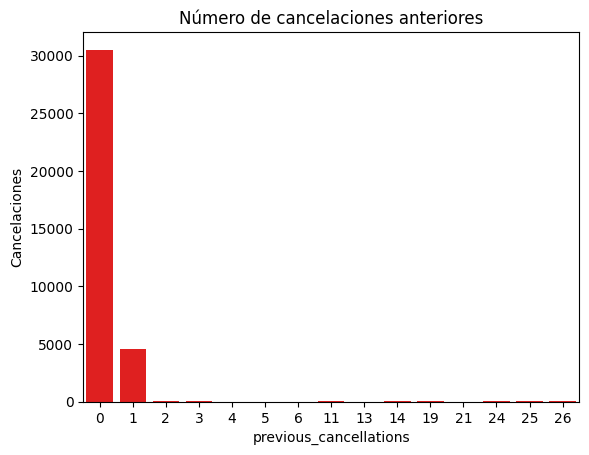

In [ ]:
# relación con target:
sns.countplot(x="previous_cancellations", data= train_set[train_set["is_canceled"]==1], color="red")
plt.title("Número de cancelaciones anteriores")
plt.ylabel("Cancelaciones")
plt.show();

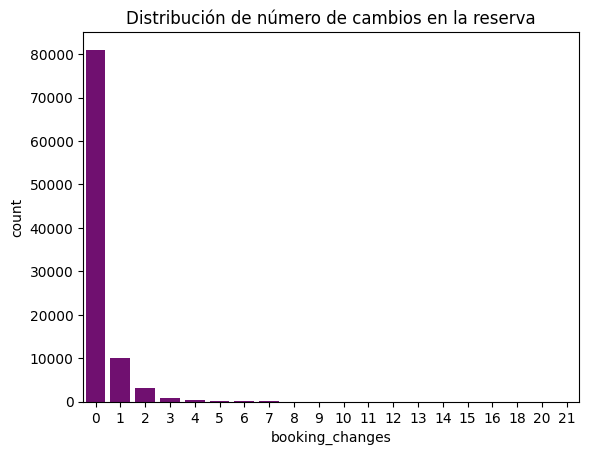

In [ ]:
# booking_changes:
sns.countplot(x="booking_changes", data= train_set, color="purple")
plt.title("Distribución de número de cambios en la reserva")
plt.show();

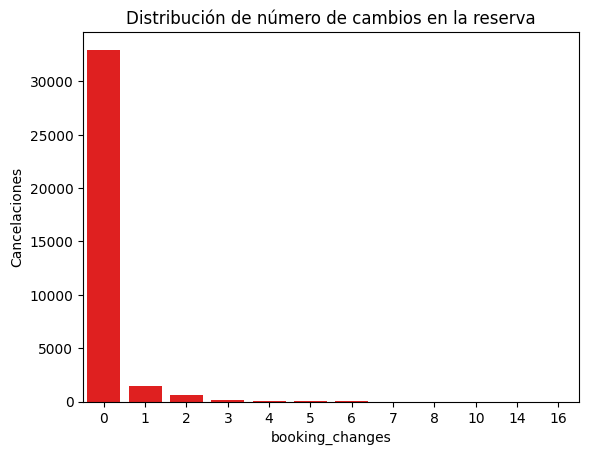

In [ ]:
sns.countplot(x="booking_changes", data= train_set[train_set["is_canceled"]==1], color="red")
plt.title("Distribución de número de cambios en la reserva")
plt.ylabel("Cancelaciones")
plt.show();

### Variables con rango amplio:

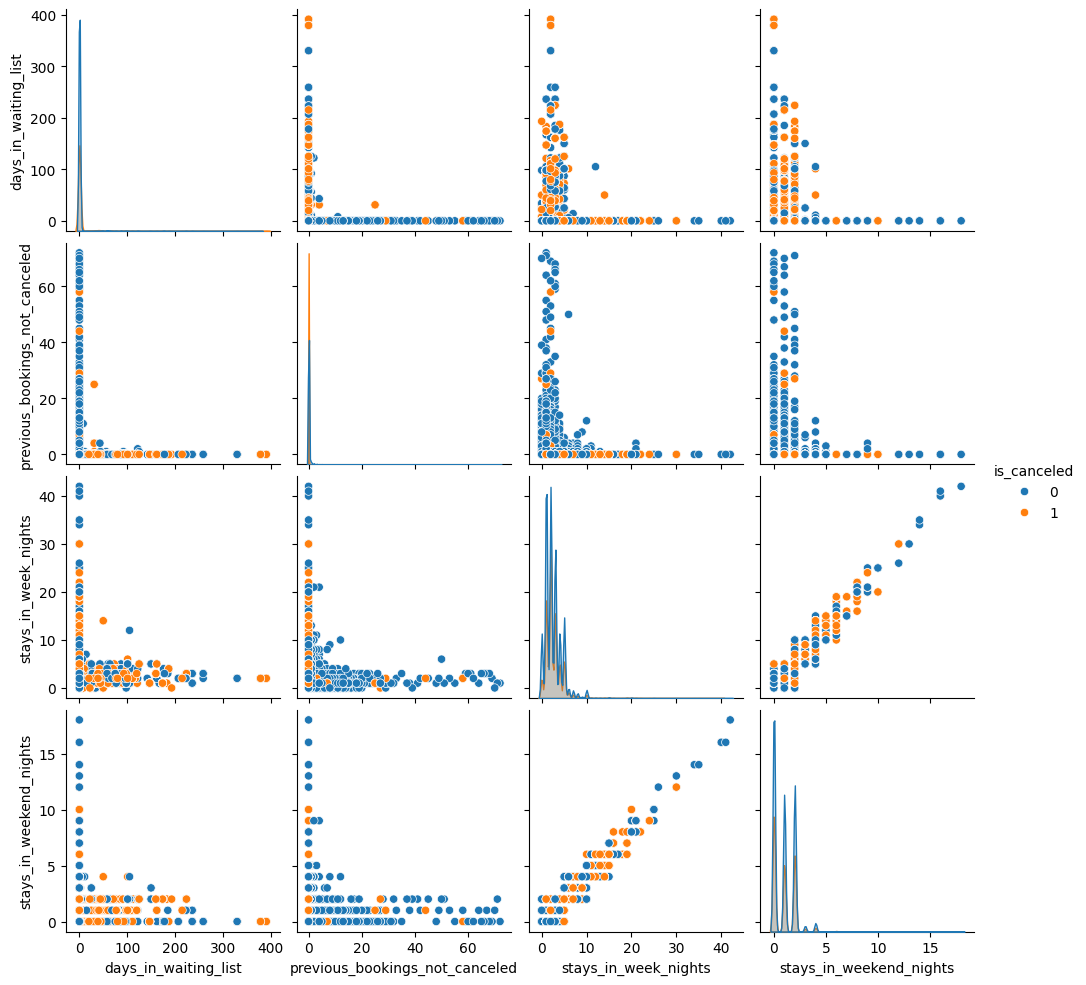

In [ ]:
# numéricas discretas con rango amplio:
num_disc_rango = ["days_in_waiting_list", "previous_bookings_not_canceled", "stays_in_week_nights", "stays_in_weekend_nights"]
sns.pairplot(train_set[num_disc_rango + [target]], hue= target)
plt.show();

### Correlación entre variables numéricas con el target:
- Correlación positiva: si la variable es positiva, aumenta la probabilidad de cancelación.
- Correlación negativa: cuando la variable es negativa, disminuye la probabilidad de cancelación.
- Para nuestro caso, variables con valores entre -0.05 y 0.05 tienen una magnitud muy baja y no aportan a nuestro target.

Así, de nuestras variables numéricas, podemos quedarnos con:

    - lead_time
    - previous_cancelations
    - adults
    - days_in_waiting_list
    - adr
    - previous_bookings_not_canceled
    - is_repeated_guest
    - booking_changes
    - required_car_parking_spaces
    - total_of_special_requests

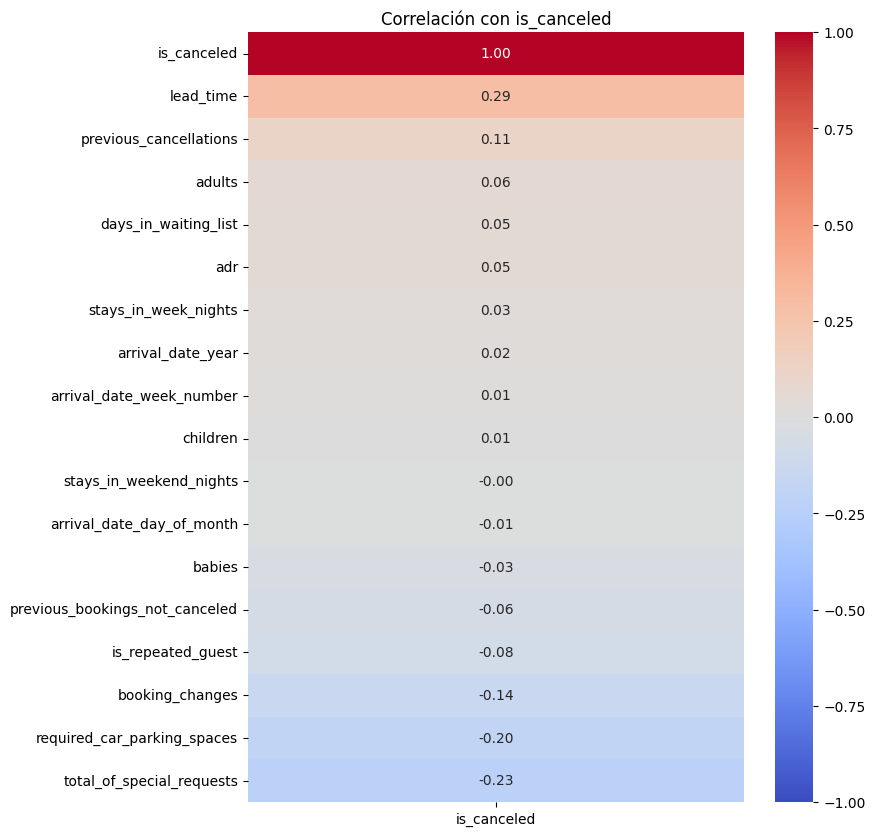

In [ ]:
corr = train_set.corr(numeric_only=True)

# Ordenar por correlación con el target
corr_target = corr["is_canceled"].sort_values(ascending=False)

plt.figure(figsize=(8,10))
sns.heatmap(
    corr_target.to_frame(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlación con is_canceled")
plt.show();

In [ ]:
corr_abs = corr["is_canceled"].abs().sort_values(ascending=False)
corr_abs

is_canceled                       1.000000
lead_time                         0.292487
total_of_special_requests         0.233946
required_car_parking_spaces       0.195043
booking_changes                   0.141941
previous_cancellations            0.110409
is_repeated_guest                 0.083567
adults                            0.060185
previous_bookings_not_canceled    0.055523
days_in_waiting_list              0.052396
adr                               0.047192
babies                            0.033624
stays_in_week_nights              0.028697
arrival_date_year                 0.017558
arrival_date_week_number          0.007929
children                          0.006207
arrival_date_day_of_month         0.006183
stays_in_weekend_nights           0.000481
Name: is_canceled, dtype: float64

La variable con mayor correlación con la cancelación es lead_time (0.29), lo que indica que cuanto mayor es la antelación de reserva, mayor es la probabilidad de cancelación. En esta correlación absoluta vemos que por debajo de 0.05, las variables que podemos descartar coinciden con las que vemos en nuestro diagrama de correlación de arriba, aunque adr aqui estaría descartada, pero vamos a incluirla.

## Análisis de variables categóricas:

In [ ]:
vars_categoricas = ["hotel","customer_type","market_segment","deposit_type",
             "meal","country",
             "distribution_channel","reserved_room_type",
             "assigned_room_type","arrival_date_month"]

for col in vars_categoricas:
    print(f"Para la columna '{col}' hay:")
    print(train_set[col].value_counts())
    print("\n")

Para la columna 'hotel' hay:
hotel
City Hotel      63573
Resort Hotel    31939
Name: count, dtype: int64


Para la columna 'customer_type' hay:
customer_type
Transient          71653
Transient-Party    20130
Contract            3264
Group                465
Name: count, dtype: int64


Para la columna 'market_segment' hay:
market_segment
Online TA        45308
Offline TA/TO    19368
Groups           15770
Direct           10070
Corporate         4202
Complementary      598
Aviation           194
Undefined            2
Name: count, dtype: int64


Para la columna 'deposit_type' hay:
deposit_type
No Deposit    83802
Non Refund    11573
Refundable      137
Name: count, dtype: int64


Para la columna 'meal' hay:
meal
BB           73867
HB           11547
SC            8531
Undefined      936
FB             631
Name: count, dtype: int64


Para la columna 'country' hay:
country
PRT    38760
GBR     9675
FRA     8382
ESP     6861
DEU     5850
       ...  
MWI        1
BWA        1
NCL        1


### Categóricas claves para el negocio:

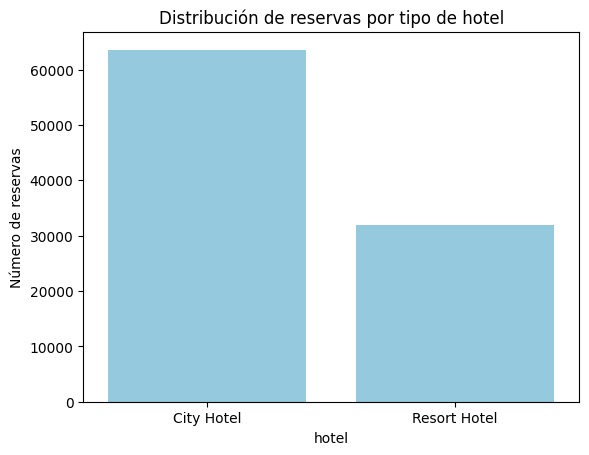

In [ ]:
# categóricas importantes para el negocio hotelero: hotel, customer_type, meal, reserved_room_type, country, deposit_type
sns.countplot(x="hotel", data=train_set, color="skyblue")
plt.title("Distribución de reservas por tipo de hotel")
plt.ylabel("Número de reservas")
plt.show();


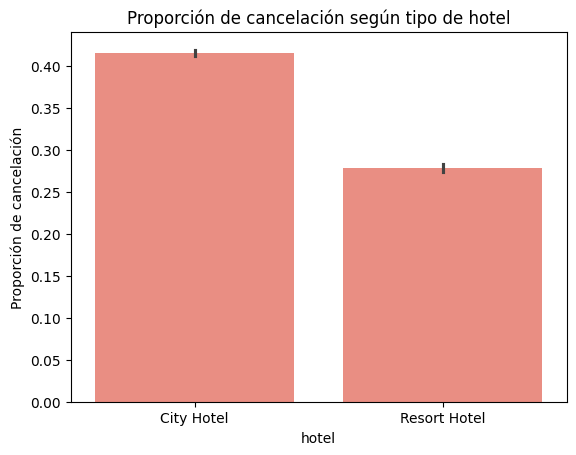

In [ ]:
# relación con target:
sns.barplot(x="hotel", y="is_canceled", data=train_set, color="salmon")
plt.title("Proporción de cancelación según tipo de hotel")
plt.ylabel("Proporción de cancelación")
plt.show();

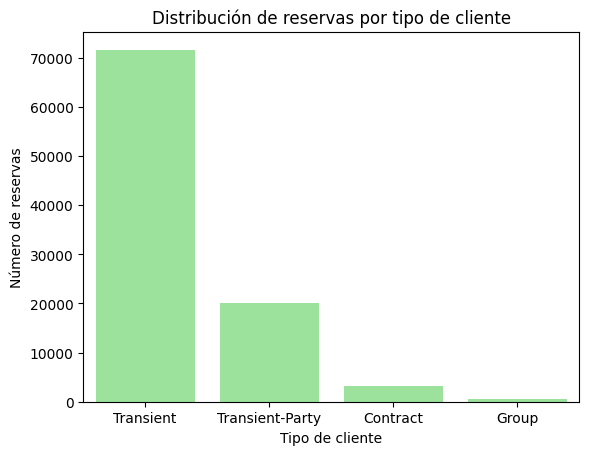

In [ ]:
# customer_type:
sns.countplot(x="customer_type", data=train_set, color="lightgreen")
plt.title("Distribución de reservas por tipo de cliente")
plt.xlabel("Tipo de cliente")
plt.ylabel("Número de reservas")
plt.show();

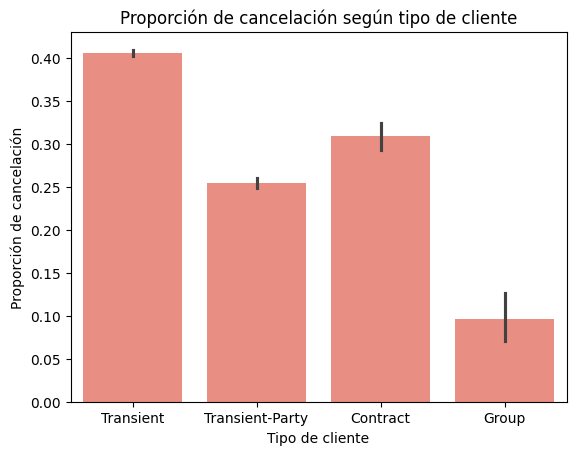

In [ ]:
# relación con target:
# transient - que reserva para sí mismo
# transient-party - que reserva para un grupo de personas
# contract - que reserva a través de una empresa
# group - que reserva para un grupo de personas, para eventos, bodas, etc.
sns.barplot(x="customer_type", y="is_canceled", data=train_set, color="salmon")
plt.title("Proporción de cancelación según tipo de cliente")
plt.xlabel("Tipo de cliente")
plt.ylabel("Proporción de cancelación")
plt.show();

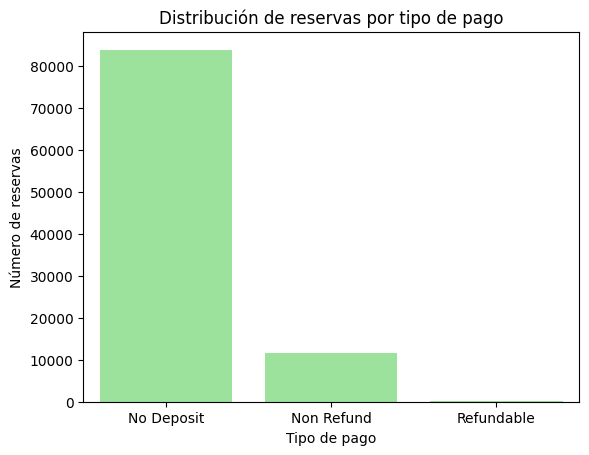

In [ ]:
# deposit_type:
sns.countplot(x="deposit_type", data=train_set, color="lightgreen")
plt.title("Distribución de reservas por tipo de pago")
plt.xlabel("Tipo de pago")
plt.ylabel("Número de reservas")
plt.show();

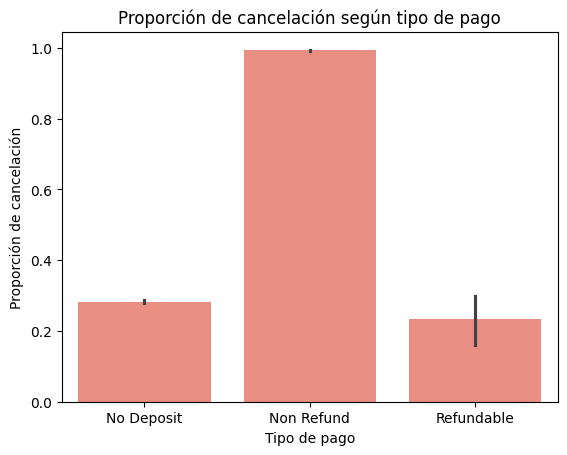

In [ ]:
# deposit_type:
sns.barplot(x="deposit_type", y="is_canceled", data=train_set, color="salmon")
plt.title("Proporción de cancelación según tipo de pago")
plt.xlabel("Tipo de pago")
plt.ylabel("Proporción de cancelación")
plt.show();

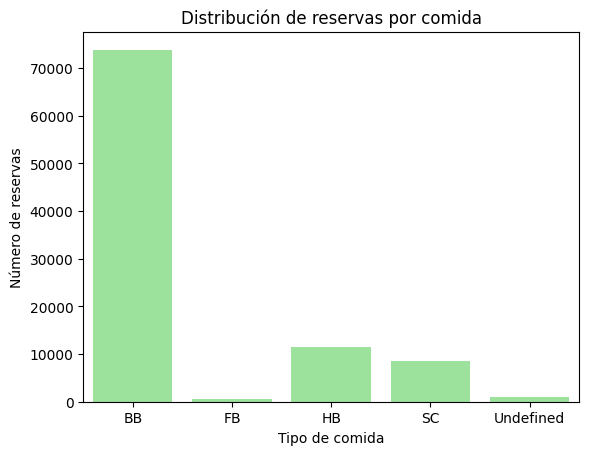

In [ ]:
# meal:
# BB - Bed & Breakfast
# HB - Half Board (desayuno y una comida)
# FB - Full Board (desayuno, comida y cena) 
# SC - Self Catering (sin comidas)
sns.countplot(x="meal", data=train_set, color="lightgreen")
plt.title("Distribución de reservas por comida")
plt.xlabel("Tipo de comida")
plt.ylabel("Número de reservas")
plt.show();

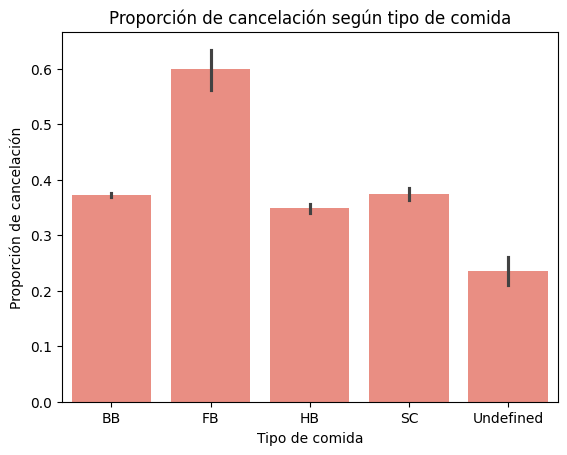

In [ ]:
# relación con target:
sns.barplot(x="meal", y="is_canceled", data=train_set, color="salmon")
plt.title("Proporción de cancelación según tipo de comida")
plt.xlabel("Tipo de comida")
plt.ylabel("Proporción de cancelación")
plt.show();

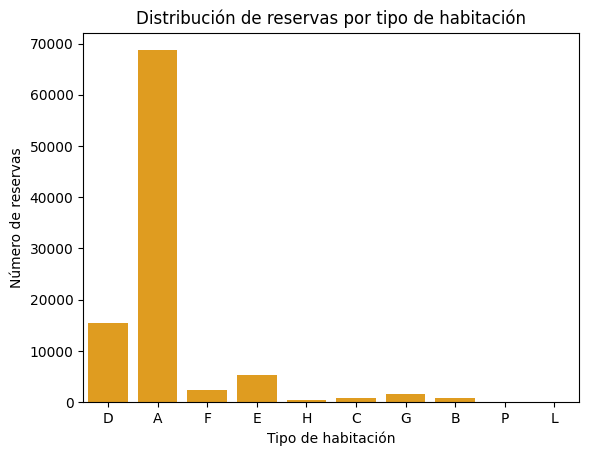

In [ ]:
# reserved_room_type:
sns.countplot(x="reserved_room_type", data=train_set, color="orange")
plt.title("Distribución de reservas por tipo de habitación")
plt.xlabel("Tipo de habitación")
plt.ylabel("Número de reservas")
plt.show();

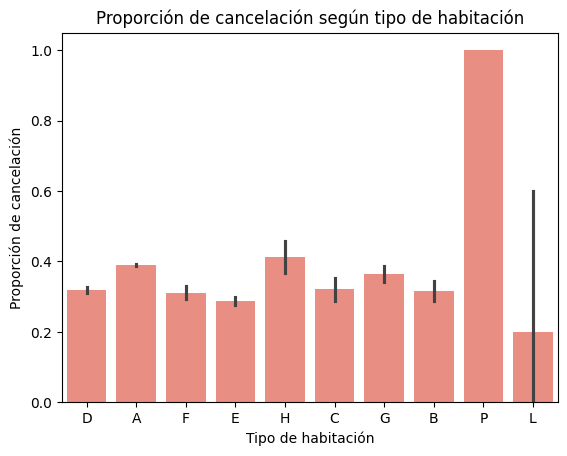

In [ ]:
# relación con target:
sns.barplot(x="reserved_room_type", y="is_canceled", data=train_set, color="salmon")
plt.title("Proporción de cancelación según tipo de habitación")
plt.xlabel("Tipo de habitación")
plt.ylabel("Proporción de cancelación")
plt.show();

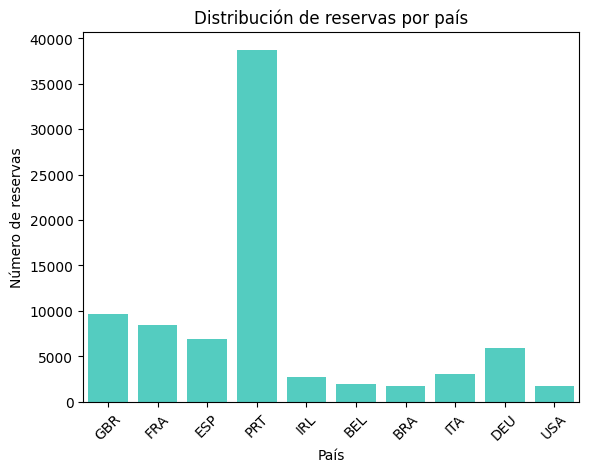

In [ ]:
#  country:
top_countries = train_set['country'].value_counts().head(10).index
sns.countplot(x='country', data=train_set[train_set['country'].isin(top_countries)], color='turquoise')
plt.xticks(rotation=45)
plt.title("Distribución de reservas por país")
plt.xlabel("País")
plt.ylabel("Número de reservas")
plt.show();

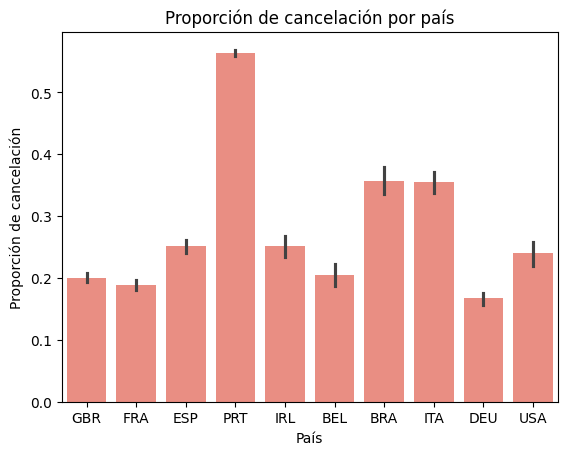

In [ ]:
# relación con target:
top_countries = train_set['country'].value_counts().head(10).index
sns.barplot(
    x='country', 
    y='is_canceled', 
    data=train_set[train_set['country'].isin(top_countries)],
    color='salmon'
)

plt.title("Proporción de cancelación por país")
plt.xlabel("País")
plt.ylabel("Proporción de cancelación")
plt.show();

### Categóricas claves para valorar la distribución:

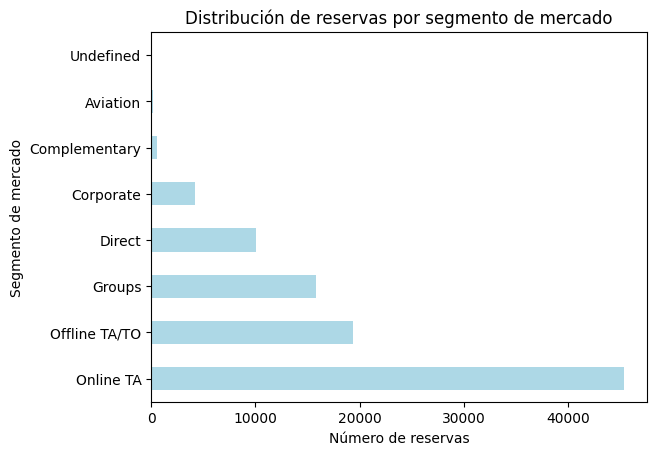

In [ ]:
# market_segment:
train_set['market_segment'].value_counts().plot(kind='barh', color='lightblue')
plt.xlabel("Número de reservas")
plt.ylabel("Segmento de mercado")
plt.title("Distribución de reservas por segmento de mercado")
plt.show()

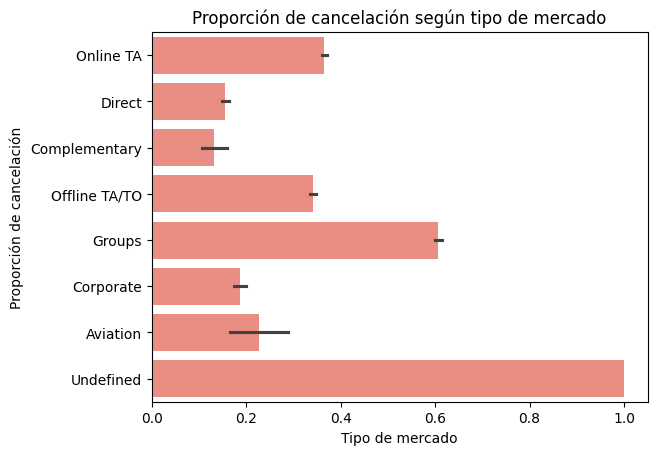

In [ ]:
sns.barplot(y="market_segment", x="is_canceled", data=train_set, color="salmon")
plt.title("Proporción de cancelación según tipo de mercado")
plt.xlabel("Tipo de mercado")
plt.ylabel("Proporción de cancelación")
plt.show();

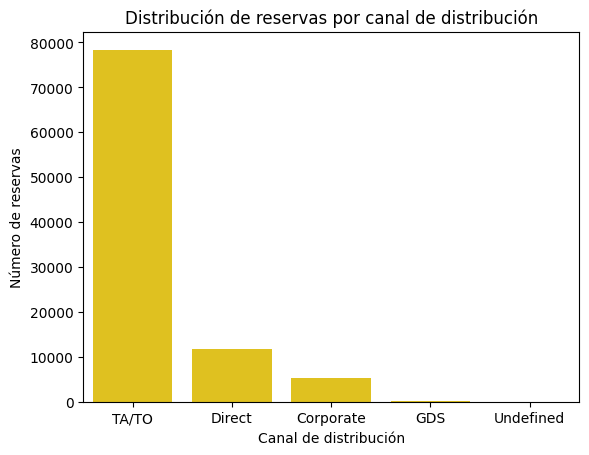

In [ ]:
# distribution_channel:
sns.countplot(x="distribution_channel", data=train_set, color="gold")
plt.title("Distribución de reservas por canal de distribución")
plt.xlabel("Canal de distribución")
plt.ylabel("Número de reservas")
plt.show();

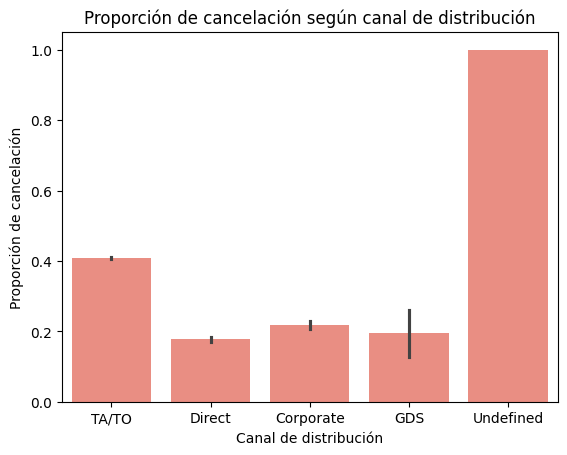

In [ ]:
# relación con target:
sns.barplot(x="distribution_channel", y="is_canceled", data=train_set, color="salmon")
plt.title("Proporción de cancelación según canal de distribución")
plt.xlabel("Canal de distribución")
plt.ylabel("Proporción de cancelación")
plt.show();

### Variable binaria:

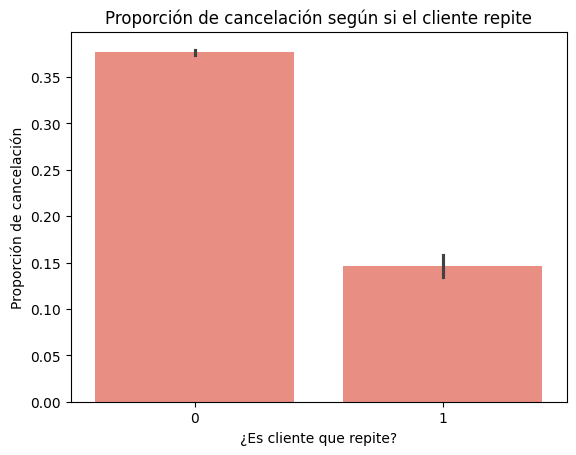

In [ ]:
# is_repeated_guest:
sns.barplot(
    x="is_repeated_guest",
    y="is_canceled",
    data=train_set,
    color="salmon"
)
plt.title("Proporción de cancelación según si el cliente repite")
plt.xlabel("¿Es cliente que repite?")
plt.ylabel("Proporción de cancelación")
plt.show();

- La variable assigned_room_type es redundante respecto a la variable reserved_room_type, que es más relevante para nuestro modelo. No la vamos a visualizar.

## Análisis temporal para detectar estacionalidad:
Nuestro target puede verse afectado por las variables de tiempo que tenemos. Veamos la relación que tienen: 

In [ ]:
# distribución de cancelaciones por año:
X_train.arrival_date_year.value_counts()

arrival_date_year
2016    45355
2017    32550
2015    17607
Name: count, dtype: int64

In [ ]:
# Agrupamos por años y meses y calculamos la media de las cancelaciones, para establecer temporalidad:
df_train = X_train.copy()
df_train["is_canceled"] = y_train

cancel_by_month = (df_train.groupby(["arrival_date_year", "arrival_date_month"])["is_canceled"].mean() * 100).sort_index()
print(cancel_by_month)

arrival_date_year  arrival_date_month
2015               August                41.241469
                   December              32.715517
                   July                  45.235935
                   November              20.378151
                   October               34.606685
                   September             40.650012
2016               April                 37.764004
                   August                35.448954
                   December              36.286645
                   February              34.440503
                   January               24.916201
                   July                  32.984004
                   June                  39.084006
                   March                 30.482115
                   May                   35.187698
                   November              36.968160
                   October               40.540541
                   September             37.294036
2017               April                 43.

- Inicialmente, hay aproximadamente 3 veces más cancelaciones en el 2016 que en el 2015.
- Sin embargo, al revisar la media de las cancelaciones por meses y años, vemos que no tenemos información de todos los meses de los años:
    - del 2015, tenemos información de 6 meses, de julio a diciembre.
    - del 2016, tenemos información de todos los meses del año.
    - del 2017 tenemos información de 8 meses, de enero a agosto solamente. 
- A partir de esto, vemos que en el 2015 el mayor mes de cancelación fue en julio; en el 2016, fue en octubre; en 2017 fue mayor y similar en abril, mayo y junio.

#### Veámoslo gráficamente con un heatmap:

In [ ]:
# ordenamos los meses para que se visualicen en orden temporal y no alfabético:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]
# pd.Categorical lo usamos para convertir la col arrival_date_month en un tipo categórico ordenado, en vez de str ya que los ordena alfabéticamente.
df_hotel["arrival_date_month"] = pd.Categorical(
    df_hotel["arrival_date_month"],
    categories=month_order,
    ordered=True
)

In [ ]:
# Creamos la tabla pivote para visualizar la media de cancelaciones por año y mes, con los meses ordenados:
pivot = (df_hotel.groupby(["arrival_date_year", "arrival_date_month"])["is_canceled"].mean().unstack() * 100)
# unstack convierte la segunda col arrival_date_month en columnas y deja los años como filas, y 
# resulta una matriz tipo tabla con años vs meses

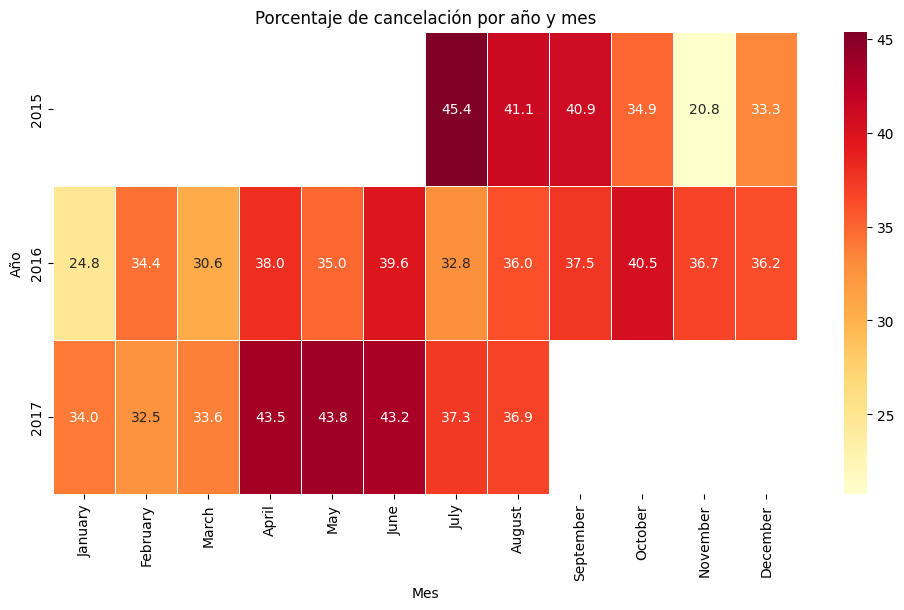

In [ ]:
# Dibujamos el heatmap:
plt.figure(figsize=(12,6))

sns.heatmap(
    pivot, # usa la tabla pivote
    annot=True, # muestra los valores numéricos dentro de cada celda
    fmt=".1f", # con un decimal
    cmap="YlOrRd", # escala de colores amarillo a rojo
    linewidths=0.5 # separación entre celdas
)

plt.title("Porcentaje de cancelación por año y mes")
plt.ylabel("Año")
plt.xlabel("Mes")
plt.show();

### Resultados visuales:
- En el 2015, hubo más cancelaciones en julio, agosto y septiembre, temporada de verano.
- En el 2016, la tasa de cancelaciones se concentró en abril, junio y octubre, siendo octubre el mes con más cancelaciones, no hay una temporada clara.
- En el 2017, se concentraron las cancelaciones entre abril, mayo y junio, estando bastante igualadas en porcentaje, en la temporada de primavera.

## Segmentación de clientes:


Veamos cómo diferentes segmentos de clientes afectan la cancelación de reservas:

### Tipo de cliente:
- Transient - que reserva para sí mismo
- Transient-party - que reserva para un grupo de personas
- Contract - que reserva a través de una empresa
- Group - que reserva para un grupo de personas, para eventos, bodas, etc.

    - Hay una proporción mayor en cancelaciones para las reservas de tipo 'Transient', que indica que los clientes individuales o familiares cancelan con mayor frecuencia.
    - Por otro lado, los clientes de tipo 'Contract' y 'Group' presentan porcentajes menores de cancelaciones, lo cual sugiere que las reservas corporativas o grupales son más comprometidas y menos propensas a cancelarse.

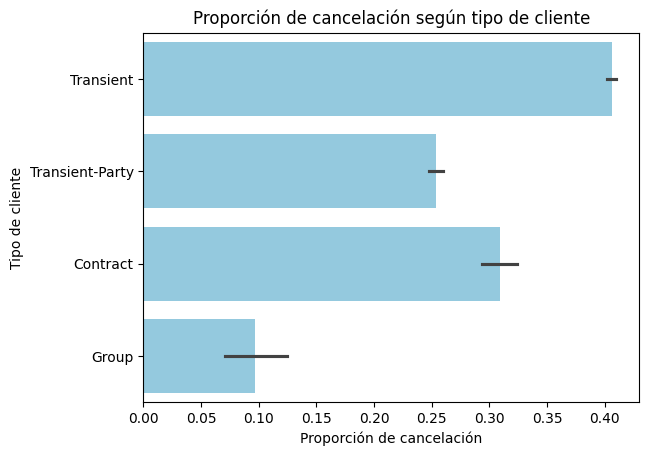

In [ ]:
sns.barplot(
    y="customer_type",
    x="is_canceled",
    data=train_set,
    color="skyblue"
)
plt.title("Proporción de cancelación según tipo de cliente")
plt.xlabel("Proporción de cancelación")
plt.ylabel("Tipo de cliente")
plt.show();

### Segmentación del mercado:
- Las reservas que se realizaron mediante agencias online ('Online TA') tienen una mayor proporción de cancelación que las reservas directas o corporativas.
- Esto coincide con el comportamiento reflejado en 'customer_type', ya que los clientes individuales reservan más a través de agencias o canales online, a diferencia de las reservas corporativas o grupales que se realizan directamente con el hotel.

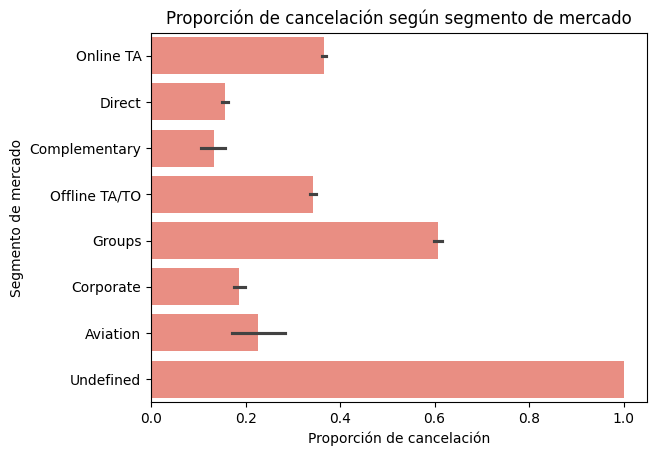

In [ ]:
sns.barplot(
    y="market_segment",
    x="is_canceled",
    data=train_set,
    color="salmon"
)
plt.title("Proporción de cancelación según segmento de mercado")
plt.xlabel("Proporción de cancelación")
plt.ylabel("Segmento de mercado")
plt.show()

### Canal de distribución:
- Las reservas realizadas por canales directos o corporativos muestran menor riesgo de cancelación.
- Los canales de agencias (TA/TO) presentan una proporción mayor de cancelaciones, reforzando la tendencia de que las reservas de clientes particulares son más inestables.

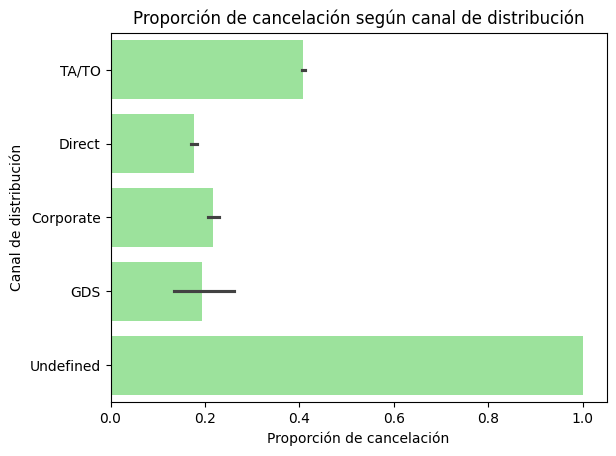

In [ ]:
sns.barplot(
    y="distribution_channel",
    x="is_canceled",
    data=train_set,
    color="lightgreen"
)
plt.title("Proporción de cancelación según canal de distribución")
plt.xlabel("Proporción de cancelación")
plt.ylabel("Canal de distribución")
plt.show();

### Correlaciones de variables categóricas:

- Si la diferencia entre la categoría más alta y la más baja es mayor a 15%-20%, la variable es importante.
- Si la diferencia es menor a 15%, la variable posiblemente no nos aporte mucho al modelo.
- Si algunas categorías tienen valores extremos de 0%-100% pero tienen pocas filas, puede ser ruido y no aportar a nuestro modelo.
- Las variables con muchas categorías (como **country**), pueden necesitar una codificación especial o agrupación por continentes o regiones.

In [ ]:
vars_categoricas = ["hotel", "customer_type", "market_segment", "deposit_type", "meal", 
                    "country", "distribution_channel", "customer_type", "reserved_room_type",
                    "assigned_room_type", "arrival_date_month", "is_repeated_guest"]

for col in vars_categoricas:
    print(f"Variable: {col}\n")
    display(pd.crosstab(train_set[col],
                        train_set["is_canceled"],
                        normalize="index"))

Variable: hotel



is_canceled,0,1
hotel,,
City Hotel,0.584918,0.415082
Resort Hotel,0.722440,0.277560


Variable: customer_type



is_canceled,0,1
customer_type,,
Contract,0.691176,0.308824
Group,0.903226,0.096774
Transient,0.594044,0.405956
Transient-Party,0.746051,0.253949


Variable: market_segment



...

is_canceled,0,1
assigned_room_type,,
A,0.557176,0.442824
B,0.765834,0.234166
C,0.817313,0.182687
D,0.747395,0.252605
E,0.750481,0.249519
F,0.748755,0.251245
G,0.694540,0.305460
H,0.648506,0.351494
I,0.982877,0.017123


Variable: arrival_date_month



is_canceled,0,1
arrival_date_month,,
January,0.694644,0.305356
February,0.667759,0.332241
March,0.680254,0.319746
April,0.593909,0.406091
May,0.604239,0.395761
June,0.587546,0.412454
July,0.625521,0.374479
August,0.623412,0.376588
September,0.610650,0.389350


Variable: is_repeated_guest



is_canceled,0,1
is_repeated_guest,,
0,0.623612,0.376388
1,0.853884,0.146116


Así, viendo los resultados del crosstab con el target, las variables con las que podemos quedarnos son:

    - hotel
    - customer_type
    - market_segment: el número de reservas de la categoría **Undefined** es muy bajo, aunque el porcentaje de las cancelaciones es del 100% y puede considerarse ruido. Sin embargo, en la etapa de modelado se puede tratar.
    - deposit_type
    - meal
    - country (que habría que codificarla o agruparla por continentes o regiones)
    - distribution_channel: al igual que en **market_segment**, el número de reservas de la categoría **Undefined** es muy bajo, el porcentaje de las cancelaciones es del 100% y puede considerarse ruido. Sin embargo, en la etapa de modelado se puede tratar.
    - reserved_room_type
    - customer_type
    - is_repeated_guest

Aunque **assigned_room_type** tiene la concentración de valores que buscamos. En realidad, a nuestro modelo no le sirve para predecir las cancelaciones, ya que assigned_room_type son las habitaciones que finalmente se asignan.

La variable **reserved_room_type** tiene más sentido para el negocio porque es la habitación de preferencia del cliente. Aunque tenga una señal baja, la utilizaremos.

### Conclusión del EDA: 

- Hay patrones claros en las cancelaciones en ciertas variables, lo que indica que el target tiene gran relevancia y puede modelarse con buen potencial predictivo.
- Cuanto más tiempo de antelación tiene una reserva, mayor es la probabilidad de cancelarse.
- El tipo de cliente influye en el riesgo de cancelaciones, siendo los clientes individuales los que más cancelan, respecto a los clientes corporativos o de grupos.
- El canal de reserva es importante, puesto que las reservas realizadas mediante agencias online tienen una mayor tasa de cancelación. Los canales directos de reservas son más estables.
- El precio tiene un comportamiento irregular en las reservas. Necesita un tratamiento concreto para poder ser empleado en el modelo.
- Algunos meses presentan mayor proporción de cancelación. Hay un comportamiento temporal en el cliente.

In [ ]:
# Calculamos la matriz de correlaciones solo con variables numéricas
corr = df.corr(numeric_only=True)

# Ahora sí calculamos la correlación absoluta con el target
corr_abs = corr["is_canceled"].abs().sort_values(ascending=False)

corr_abs

is_canceled                       1.000000
lead_time                         0.293123
total_of_special_requests         0.234658
required_car_parking_spaces       0.195498
booking_changes                   0.144381
previous_cancellations            0.110133
is_repeated_guest                 0.084793
agent                             0.083114
adults                            0.060017
previous_bookings_not_canceled    0.057358
days_in_waiting_list              0.054186
adr                               0.047557
babies                            0.032491
stays_in_week_nights              0.024765
company                           0.020642
arrival_date_year                 0.016660
arrival_date_week_number          0.008148
arrival_date_day_of_month         0.006130
children                          0.005048
stays_in_weekend_nights           0.001791
Name: is_canceled, dtype: float64

In [ ]:
corr_abs = corr["is_canceled"].abs().sort_values(ascending=False)
corr_abs

is_canceled                       1.000000
lead_time                         0.293123
total_of_special_requests         0.234658
required_car_parking_spaces       0.195498
booking_changes                   0.144381
previous_cancellations            0.110133
is_repeated_guest                 0.084793
agent                             0.083114
adults                            0.060017
previous_bookings_not_canceled    0.057358
days_in_waiting_list              0.054186
adr                               0.047557
babies                            0.032491
stays_in_week_nights              0.024765
company                           0.020642
arrival_date_year                 0.016660
arrival_date_week_number          0.008148
arrival_date_day_of_month         0.006130
children                          0.005048
stays_in_weekend_nights           0.001791
Name: is_canceled, dtype: float64

**PREPROCESADO PARA MODELADO**


In [ ]:
# Eliminación de variables con leakage
cols_to_drop = [
    "assigned_room_type",
    "booking_changes",
    "days_in_waiting_list"
]

df_model = df_hotel.drop(columns=cols_to_drop)


Se eliminan variables que podrían depender de eventos posteriores a la reserva y generar fuga de información.

In [ ]:
# Transformaciones logaritmicas 
import numpy as np

df_model["adr"] = df_model["adr"].clip(lower=0)
df_model["adr_log"] = np.log1p(df_model["adr"])
df_model = df_model.drop(columns=["adr"])

Tratamiento de Missing Values

In [ ]:
df_hotel["children"] = df_hotel["children"].fillna(0)                                   # <- si no hay dato, asumimos 0 niños

In [ ]:
# Agrupación por país
def group_country(country):
    europe = ["PRT","GBR","ESP","FRA","DEU","ITA"]
    america = ["USA","BRA","CAN"]
    asia = ["CHN","IND","JPN"]

    if country in europe:
        return "Europe"
    elif country in america:
        return "America"
    elif country in asia:
        return "Asia"
    else:
        return "Other"

df_model["country_grouped"] = df_model["country"].apply(group_country)
df_model = df_model.drop(columns=["country"])

In [ ]:
df_model.isna().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
deposit_type                      0
customer_type                     0
required_car_parking_spaces       0
total_of_special_requests         0
adr_log                           0
country_grouped                   0
dtype: int64

**FEATURES ENGINEERING**


In [ ]:
# Total huéspedes
df_model["total_nights"] = (
    df_model["stays_in_weekend_nights"] +  df_model["stays_in_week_nights"])

# Ratio por Noche
df_model["price_per_night"] = df_model["adr_log"] / df_model["total_nights"].replace(0, 1)

# Cliente corporativo vs individual
df_model["is_individual"] = df_model["customer_type"].apply(lambda x: 1 if x == "Transient" else 0)

# Total noches
df_model["total_nights"] = (df_model["stays_in_weekend_nights"] + df_model["stays_in_week_nights"])

# Total guests
df_model["total_guests"] = ( df_model["adults"] + df_model["children"].fillna(0) + df_model["babies"])

# Viaja con niños
df_model["has_kids"] = ((df_model["children"] + df_model["babies"]) > 0).astype(int)

# Mes numérico + temporada
month_map = {
    "January":1,"February":2,"March":3,"April":4,"May":5,"June":6,
    "July":7,"August":8,"September":9,"October":10,"November":11,"December":12
}

df_model["arrival_month_num"] = df_model["arrival_date_month"].map(month_map)        # <- mes en número
df_model["is_high_season"] = df_model["arrival_month_num"].isin([6,7,8,12]).astype(int)  # <- verano + diciembre (0/1)


Se generaron nuevas variables basadas en conocimiento de negocio con el objetivo de:  
- Reducir dimensionalidad (ej. total_nights, total_guests).  
- Capturar patrones no lineales (ej. price_per_night).  
- Modelar comportamientos específicos del cliente (has_kids, is_individual).  
- Incorporar efectos estacionales simplificados (high_season).  
- Estas transformaciones permiten al modelo capturar señales más robustas sin introducir fuga de información.  

**SEPARAR X e y**

In [ ]:
# Variable objetivo
y = df_model["is_canceled"]

# Variables predictoras
X = df_model.drop("is_canceled", axis=1)

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (119390, 32)
Shape y: (119390,)


Se separa la variable objetivo (is_canceled) del conjunto de variables predictoras para iniciar el proceso de modelado.

**TRAIN/TEST SPLIT**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (95512, 27)
Test size: (23878, 27)


Se realiza una división estratificada para conservar la proporción de cancelaciones en ambos conjuntos.

**SEPARAR VARIABLES NUMÉRICAS Y CATEGÓRICAS**

In [ ]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

print("Numéricas:", len(num_cols))
print("Categóricas:", len(cat_cols))

Numéricas: 17
Categóricas: 10


**CONSTRUIMOS PIPELINES INTERNOS**

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

📘 Tratamiento de variables mediante Pipeline  

Con el objetivo de garantizar un flujo de modelado robusto y evitar fuga de información, se construyen pipelines diferenciados para variables numéricas y categóricas.

Para variables numéricas se aplica:  
- Imputación mediante mediana, por su robustez frente a valores extremos.  
- Escalado estándar (StandardScaler) para normalizar la distribución y facilitar la convergencia del modelo.

Para variables categóricas se aplica:  
- Imputación mediante la categoría más frecuente.  
- Codificación One-Hot para transformar variables textuales en formato numérico.  

Estas transformaciones se integran mediante un ColumnTransformer, permitiendo que cada tipo de variable reciba el tratamiento adecuado dentro de un único flujo reproducible.

Este enfoque asegura que todas las transformaciones se ajusten únicamente con los datos de entrenamiento, evitando contaminación del conjunto de test.

**MODELADO BASELINE**
- Preprocesado  
- Modelado  

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

log_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

Se selecciona la Regresión Logística como modelo baseline por tratarse de un problema de clasificación binaria y por su equilibrio entre simplicidad, estabilidad e interpretabilidad.  
Este modelo permite establecer una referencia clara de rendimiento antes de introducir modelos más complejos como Random Forest.  
Además, su naturaleza lineal facilita la interpretación del impacto de las variables en la probabilidad de cancelación.

- Entrenamos

In [ ]:
log_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

- Evaluamos

In [ ]:
from sklearn.metrics import balanced_accuracy_score, classification_report, roc_auc_score

y_pred = log_model.predict(X_test)
y_proba = log_model.predict_proba(X_test)[:, 1]

print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Balanced Accuracy: 0.8112005017067996
ROC-AUC: 0.902357739898716

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.83      0.85     14907
           1       0.74      0.79      0.76      8971

    accuracy                           0.82     23878
   macro avg       0.80      0.81      0.81     23878
weighted avg       0.82      0.82      0.82     23878



Evaluación del modelo baseline

El modelo de Regresión Logística alcanza una Balanced Accuracy del 81.1%, lo que indica un buen equilibrio en la predicción de ambas clases.

Se utiliza la métrica ROC-AUC para evaluar la capacidad discriminativa del modelo, es decir, su habilidad para distinguir entre reservas canceladas y no canceladas. 
A diferencia de la accuracy, la métrica ROC-AUC no depende de un umbral de decisión fijo y resulta especialmente adecuada en contextos con cierto desbalance de clases.

En particular, el modelo identifica correctamente el 79% de las cancelaciones (recall clase 1), lo que resulta especialmente relevante desde el punto de vista del negocio, ya que permite anticipar un elevado porcentaje de cancelaciones potenciales.

En conjunto, estos resultados posicionan a la Regresión Logística como un baseline sólido para comparaciones posteriores con modelos más complejos.

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced"),
    "GradientBoosting": GradientBoostingClassifier()
}

results = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    
    results[name] = {
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }

results